# Phoenix Park, Dublin, Vegetation analysis 2017-2026

## 1. Objective

It's been a hot, dry July in Europe in 2026, even in lush, green Ireland!  
I don't remember seeing the grass in Dublin so dry and yellow before - but is this really the case?  
Let's take a look at the vegetation greenness in Dublin's iconic Phoenix Park/Páirc an Fhionnuisce over the past 10 years to see if this year is really so different from recent years.  

Vegetation greeness can be quantified using NDVI (Normalized Difference Vegetation Index). NDVI is a widely used measure of vegetation greenness derived from satellite imagery. It compares the amount of near-infrared and red light reflected by the Earth's surface: healthy vegetation typically reflects strongly in the near-infrared while absorbing red light, resulting in higher NDVI values. NDVI values generally range from −1 to 1 (although the lower bound is usually closer to 0), with higher values indicating denser or healthier green vegetation and values near or below zero typically corresponding to non-vegetated surfaces such as water, bare ground or clouds.

Here is an exploratory analysis of vegetation greenness in the Phoenix Park in July over the past 10 years (2017-2026), based on NVDI calculated from Sentinel-2 data.   

## 2. Data  

- Sentinel-2 L2A   
- Phoenix Park boundary GeoJSON (sourced from https://data.gov.ie/dataset/parks-gardens-and-public-spaces-dcc)

## 3. Method  

- Search for Sentinel-2 observations for July over the Phoenix Park, Dublin, over the last 10 years (2017-2026) with less than 80% cloud cover
- Use SCL band in Sentinel-2 data to mask out pixels not classified as vegetation within the bounds of the park
- Calculate NDVI, based on bands B08 (Near Infra-Red) and B04 (Red) in the Sentinel-2 data for each scene returned by the search, for 10x10 metre pixels
- Calculate mean NDVI value per pixel per year, as well as an aggregate score for NDVI for the whole park per year (median value of the mean scores within each year)

In [1]:
# Setup
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
# Load packages
import pandas as pd
import geopandas as gpd
from odc.stac import load
import numpy as np
import pystac_client
import planetary_computer
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
from src.ndvi_funcs import calculate_scene_ndvi, plot_ndvi_map

In [3]:
# Load park boundary and reproject CRS to match Sentinel-2 data
parks = gpd.read_file('../data/dcc_parks_strategy2016_park_classification.geojson')
park = parks[parks.Name.str.contains('Phoenix')].copy()
park_utm = park.to_crs('EPSG:32629')


In [4]:
# Open link to STAC catalog (to search for Sentinel-2 observations)
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1'
    )


In [5]:
# Get Sentinel-2 observations and calculate NDVI
annual_maps = {}
results = []

for year in range(2017, 2027):

    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=park.total_bounds,
        datetime=f"{year}-07-01/{year}-07-31",
        query={"eo:cloud_cover": {"lt": 80}}, #relax the cloud cover filter to <80%
    )

    items = list(search.items())

    year_ndvi_maps = []

    for item in items:

        mean_ndvi, vegetation_pixels, ndvi_map = (
            calculate_scene_ndvi(item, park_utm)
        )

        results.append({
            "year": year,
            "date": item.datetime.date(),
            "cloud_cover": item.properties["eo:cloud_cover"],
            "mean_ndvi": mean_ndvi,
            "vegetation_pixels": vegetation_pixels,
            "item_id": item.id,
        })

        year_ndvi_maps.append(ndvi_map)

    # Create the annual pixel-level composite
    if year_ndvi_maps:
        annual_maps[year] = xr.concat(
            year_ndvi_maps,
            dim="scene"
        ).mean(
            dim="scene",
            skipna=True
        )

## 4. Results  


In [6]:
results_df = pd.DataFrame(results)

annual_median_ndvi = (
    results_df
    .groupby("year")["mean_ndvi"]
    .median()
)

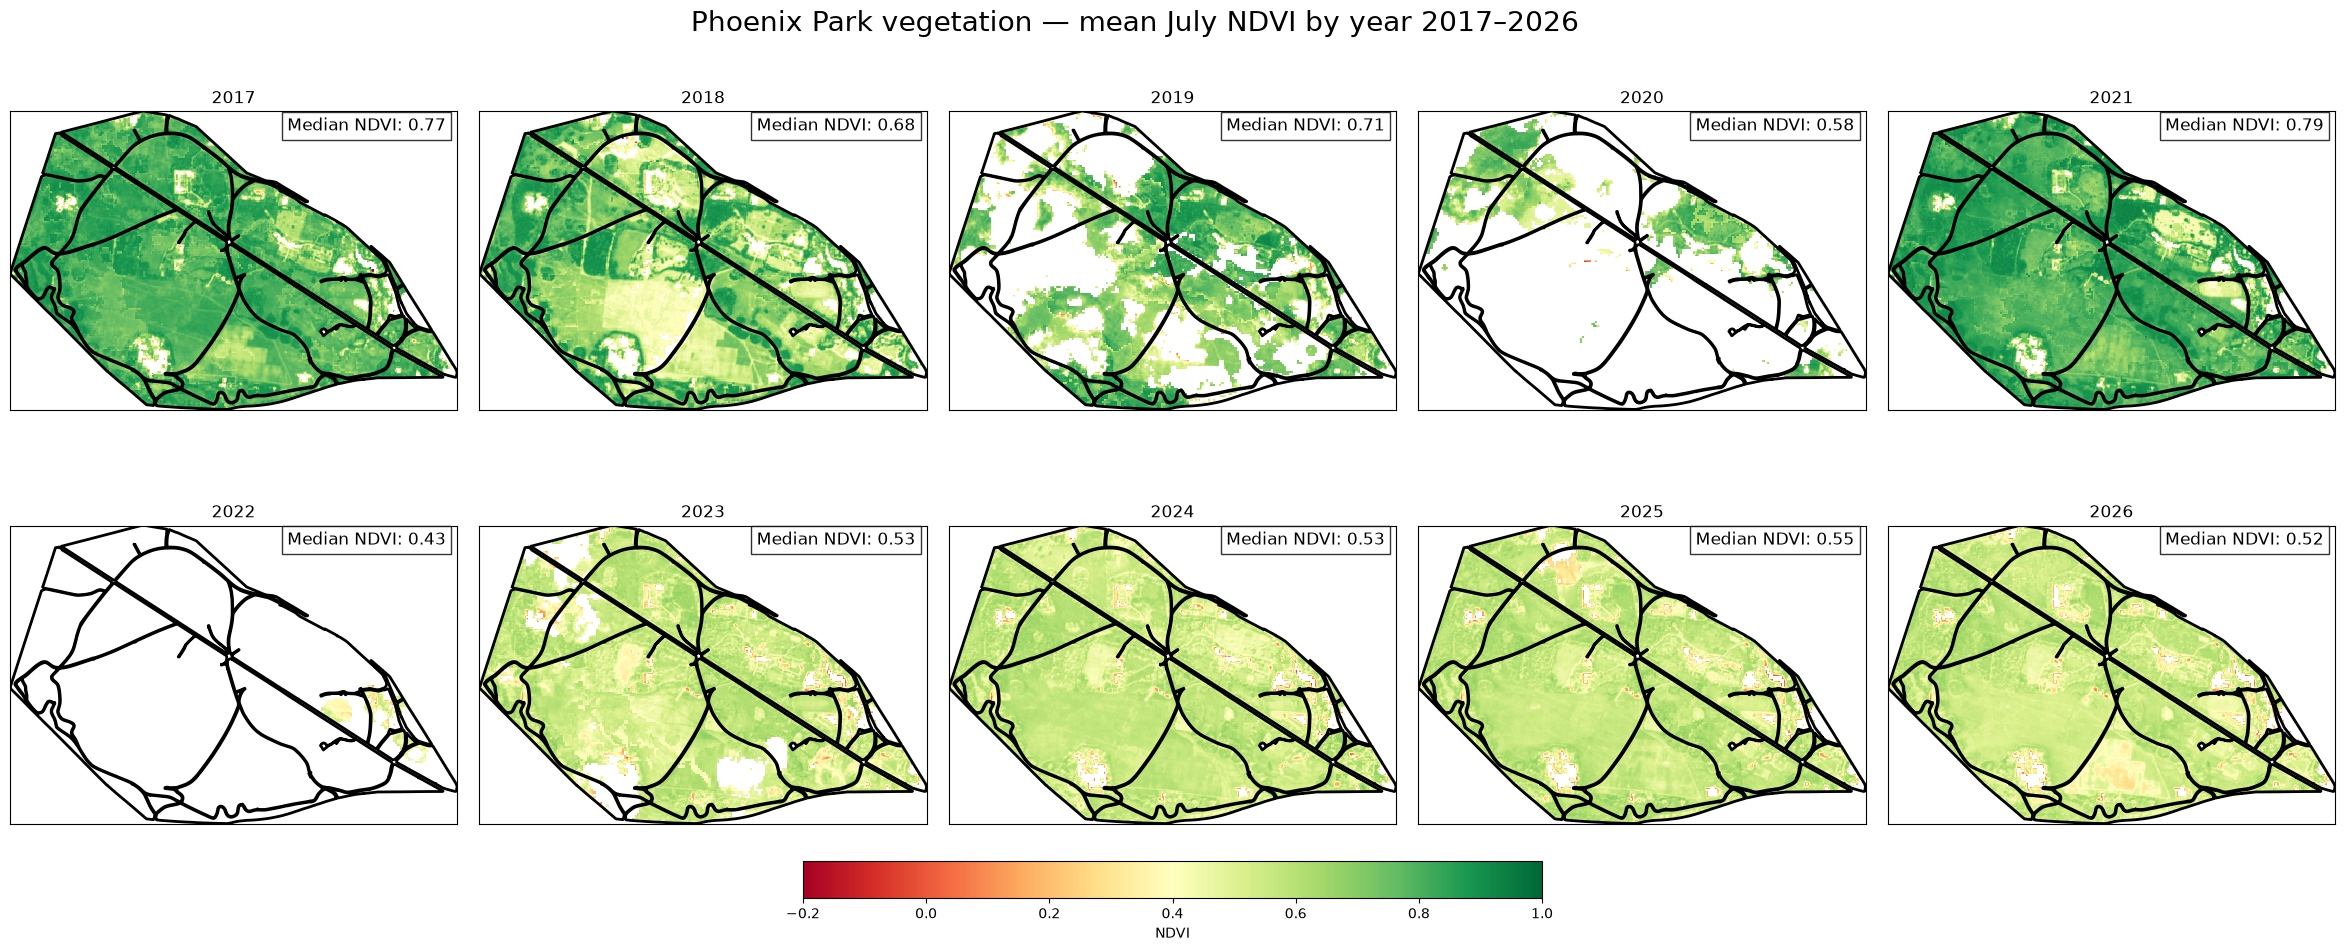

In [15]:
import matplotlib as mpl

vmin = -0.2
vmax = 1

fig, axes = plt.subplots(
    2, 5,
    figsize=(30, 12),
    gridspec_kw={"hspace": -0.05, "wspace": 0.05}
)

fig.suptitle(
    "Phoenix Park vegetation — mean July NDVI by year 2017–2026",
    fontsize=20,
    y=0.85
)

axes = axes.flatten()

for ax, year in zip(axes, range(2017, 2027)):
    plot_ndvi_map(year, park_utm, annual_median_ndvi, annual_maps, ax, vmin, vmax)

sm = mpl.cm.ScalarMappable(
    cmap="RdYlGn",
    norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
)

sm.set_array([])

fig.colorbar(
    sm,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.04,
    label="NDVI"
)

# plt.tight_layout()
plt.show()

The maps show mean NDVI for each 10 × 10 m pixel within Phoenix Park during July of each year from 2017 to 2026. Pixels for which no valid vegetation observation was available (e.g. water, built areas, areas concealed by cloud) remain blank. The same colour scale is used across all years to allow direct visual comparison.  
In addition, an aggregate measure of NDVI per year - the median NDVI - is reported for each year.

2017–2021 generally show substantially higher NDVI (greener vegetation) than 2023–2026, with 2026 having the lowest (least green). The results suggest a decline in vegetation greenness in the later years of the study, although the magnitude of this change varies spatially across the park.
In certain years, such as 2020 and 2022, there were very few cloudless data points, so these years' results should be interpreted cautiously.

So was Dublin actually less green in July 2026 compared to recent years? It looks like the answer is yes.

## 5. Limitations

This analysis has several limitations, including (but not limited to) the following:  
- July represents only a single month of each year, so the results do not capture changes in vegetation throughout the full growing season.  
- Cloud and quality masking also mean that the number of valid observations varies between years, and the annual pixel values are composites of available observations rather than measurements taken on exactly the same day each year.  
- NDVI can also be influenced by factors other than vegetation health, including weather, seasonal conditions, atmospheric effects and park management.  
- Finally, a ten-year time series is relatively short for identifying long-term environmental trends, so the results should be interpreted as an indication of changes in vegetation greenness rather than evidence of a definitive long-term trend or its underlying causes.